# Instructions

**Please follow these instructions carefully to ensure your submission is graded correctly:**

- Fill in **your answers** in any place that says "YOUR CODE HERE" or "YOUR ANSWER HERE" in the provided `.ipynb` files.

- Do not use print statements or the variable name `_` to display your answers; instead, make sure the last line of the cell contains the variable that holds your answer.

- Your answers to code-based questions must be **generated from code**. Hardcoded answers will result in a deduction of points.  

- Do not change the **autograding cells** labelled with `"AUTOGRADING CELL - DO NOT TOUCH!"`. Modifying or deleting them may lead to incorrect grading results.

- All plots must have appropriate **axis labels** including units where applicable. Failing to do so will result in a partial deduction of points.

- Always proide **units** for quantities where applicable. Failing to do so will result in a partial deduction of points.

- The **code quality** will not be graded. However, concise, well-structured code makes it easier to awared partial points in case of errors.

- The quality of **written answers** and **figures** will be considered during grading.

- Do not use additional packages that are not part of the course **environment**. This would lead to errors during autograding.

- Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

- Submissions must be your own work, **plagiarism** from the web or peers will be checked for and sanctioned.

- Please upload only the provided `.ipynb` files, filled in with your answers.

- Please **do not** put the `.ipynb` files into archives (e.g., `.zip`, `.tar.gz`); also `.py` files will **not** be accepted. Please **do not change the file names** and do not upload additional files.

- Submission on ISIS *(for TU Berlin students)* requires **two-factor authentication**.

---

## Task 2: Merit Order of Electricity Market (28 points)

In this task you are asked to build and evaluate merit order curves for a stylised German day-ahead electricity market in a particular hour.
To solve this task, a dataset on operational power plants and some additional technology-specific data is provided:

In [1]:
url_powerplants = (
    "https://tubcloud.tu-berlin.de/s/icMJ8c89RPpaPFR/download/powerplants.csv"
)
url_technologies = (
    "https://tubcloud.tu-berlin.de/s/XjtnxyNPtPP6eDQ/download/technologies.csv"
)

The attributes contained in the two CSV files have the following units:

| Attribute      | Description                          | Unit                           |
|----------------|--------------------------------------|--------------------------------|
| `carrier`        | technology                           |                              |
| `co2_emissions`  | specific carbon dioxide emissions    | t/MWh(thermal)                |
| `color`          | HEX color code                       |                               |
| `efficiency`     | conversion efficiency                | MWh(electric) / MWh(thermal)   |
| `marginal_cost`  | short-term marginal generation cost  | €/MWh(electric)               |
| `p_max_pu`       | capacity factor in particular hour   | p.u.                           |
| `p_nom`          | nominal capacity                     | MW                             |


Assume that all hydro storage has sufficient energy filling levels to dispatch at full capacity.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

**a)** Read the powerplants dataset (i.e. `powerplants.csv`) into a `pandas.DataFrame` called `df` such that the first column is used as index. Return `df`. **(1 point)**

In [12]:
# YOUR CODE HERE
df = pd.read_csv(url_powerplants, index_col=0)
df

,efficiency,marginal_cost,p_nom,carrier,p_max_pu
3371 biomass,0.479086,15.002823,20.569100,biomass,1.000000
3371 onwind,1.000000,2.816645,206.573309,onshore wind,0.085297
3371 ror,0.876590,3.375065,44.060000,run of river,0.660853
3371 solar,1.000000,0.758468,324.967191,solar,0.159534
3372 CCGT,0.610525,37.716707,1822.000000,CCGT,1.000000
...,...,...,...,...,...
4944 PHS,0.893191,3.716771,1060.000000,pumped hydro,1.000000
5883 PHS,0.924192,3.444487,120.000000,pumped hydro,1.000000
8121 PHS,0.835107,3.924952,7.420000,pumped hydro,1.000000
8414 PHS,0.931837,3.916358,480.000000,pumped hydro,1.000000


In [4]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(df, pd.DataFrame)

**b)** Read the technologies (i.e. `technologies.csv`) as another `pandas.DataFrame` and map the specific carbon dioxide emissions to the powerplants `df` from part **a)** as a new column `co2_emissions` based on the `carrier` attribute. Return the updated `df`. **(2 points)**

In [ ]:
# YOUR CODE HERE
technologies = pd.read_csv(url_technologies, index_col=0)
df['co2_emissions'] = df['carrier'].map(technologies['co2_emissions'])
df


,efficiency,marginal_cost,p_nom,carrier,p_max_pu,co2_emissions
3371 biomass,0.479086,15.002823,20.569100,biomass,1.000000,0.0
3371 onwind,1.000000,2.816645,206.573309,onshore wind,0.085297,0.0
3371 ror,0.876590,3.375065,44.060000,run of river,0.660853,0.0
3371 solar,1.000000,0.758468,324.967191,solar,0.159534,0.0
3372 CCGT,0.610525,37.716707,1822.000000,CCGT,1.000000,0.2
...,...,...,...,...,...,...
4944 PHS,0.893191,3.716771,1060.000000,pumped hydro,1.000000,0.0
5883 PHS,0.924192,3.444487,120.000000,pumped hydro,1.000000,0.0
8121 PHS,0.835107,3.924952,7.420000,pumped hydro,1.000000,0.0
8414 PHS,0.931837,3.916358,480.000000,pumped hydro,1.000000,0.0


In [14]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(df, pd.DataFrame)

**c)** For each powerplant, compute the available capacity in MW for the given hour. Store the result in a new column `available_capacity`. Return the updated `df`. **(1 point)**

In [15]:
# YOUR CODE HERE
df['available_capacity'] = df['p_max_pu'] * df['p_nom']
df


,efficiency,marginal_cost,p_nom,carrier,p_max_pu,co2_emissions,available_capacity
3371 biomass,0.479086,15.002823,20.569100,biomass,1.000000,0.0,20.569100
3371 onwind,1.000000,2.816645,206.573309,onshore wind,0.085297,0.0,17.620043
3371 ror,0.876590,3.375065,44.060000,run of river,0.660853,0.0,29.117188
3371 solar,1.000000,0.758468,324.967191,solar,0.159534,0.0,51.843188
3372 CCGT,0.610525,37.716707,1822.000000,CCGT,1.000000,0.2,1822.000000
...,...,...,...,...,...,...,...
4944 PHS,0.893191,3.716771,1060.000000,pumped hydro,1.000000,0.0,1060.000000
5883 PHS,0.924192,3.444487,120.000000,pumped hydro,1.000000,0.0,120.000000
8121 PHS,0.835107,3.924952,7.420000,pumped hydro,1.000000,0.0,7.420000
8414 PHS,0.931837,3.916358,480.000000,pumped hydro,1.000000,0.0,480.000000


In [16]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(df, pd.DataFrame)

**d)** Identify the marginal power plant for a total demand of 80 GW in the given hour. Return the index of the marginal power plant as a string. **(2 points)**

In [35]:
# YOUR CODE HERE
cum_capacity = df['available_capacity'].cumsum()
marginal_plant = str(cum_capacity[cum_capacity >= 80000].index[0])
marginal_plant

'7023 CCGT'

In [36]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, str)

**e)** What is the resulting market clearing price in €/MWh? Return the market clearing price as a `float`. **(2 points)** 

In [101]:
# YOUR CODE HERE
market_clearing_price = float(df.loc[marginal_plant, 'marginal_cost'])
market_clearing_price

38.850814453519504

In [102]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

**f)** Compute the dispatch (in MW) for each power plant given the total demand of 80 GW in the given hour. Store the result in a new column `dispatch_1`. Return the updated `df`. **(2 points)**

In [39]:
# YOUR CODE HERE
cum_capacity = df['available_capacity'].cumsum()
demand_mw = 80000
cum_cap = df['available_capacity'].cumsum()
prev_cum_cap = cum_cap - df['available_capacity']
df['dispatch_1'] = np.clip(demand_mw - prev_cum_cap, 0, df['available_capacity'])
df

,efficiency,marginal_cost,p_nom,carrier,p_max_pu,co2_emissions,available_capacity,dispatch_1
3371 biomass,0.479086,15.002823,20.569100,biomass,1.000000,0.0,20.569100,20.569100
3371 onwind,1.000000,2.816645,206.573309,onshore wind,0.085297,0.0,17.620043,17.620043
3371 ror,0.876590,3.375065,44.060000,run of river,0.660853,0.0,29.117188,29.117188
3371 solar,1.000000,0.758468,324.967191,solar,0.159534,0.0,51.843188,51.843188
3372 CCGT,0.610525,37.716707,1822.000000,CCGT,1.000000,0.2,1822.000000,1822.000000
...,...,...,...,...,...,...,...,...
4944 PHS,0.893191,3.716771,1060.000000,pumped hydro,1.000000,0.0,1060.000000,0.000000
5883 PHS,0.924192,3.444487,120.000000,pumped hydro,1.000000,0.0,120.000000,0.000000
8121 PHS,0.835107,3.924952,7.420000,pumped hydro,1.000000,0.0,7.420000,0.000000
8414 PHS,0.931837,3.916358,480.000000,pumped hydro,1.000000,0.0,480.000000,0.000000


In [40]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(df, pd.DataFrame)

In [41]:
### AUTOGRADING CELL - DO NOT TOUCH!

**g)** Calculate the total power dispatched per technology. Return a `pandas.Series` with the technology as index and the total dispatched power as values (in GW). **(2 points)**

In [45]:
# YOUR CODE HERE
series_dispatched = df.groupby('carrier')['dispatch_1'].sum()/1000
series_dispatched

carrier
CCGT               14.741484
OCGT                3.575923
biomass             7.058776
coal               13.977858
hydro reservoir     0.000000
lignite            21.014699
nuclear             5.468000
offshore wind       0.831095
oil                 0.615200
onshore wind        2.191457
pumped hydro        0.000000
run of river        1.623394
solar               8.902116
Name: dispatch_1, dtype: float64

In [46]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)

**h)** Compute the total profit per technology given the market clearing price. Return a `pandas.Series` with the technology group as index and the total profit as values (in k€). **(2 points)**

In [58]:
# YOUR CODE HERE

series_profit = df['dispatch_1'] * (market_clearing_price - df['marginal_cost'])
series_profit = series_profit.groupby(df['carrier']).sum()/1000
series_profit


carrier
CCGT               -42.015466
OCGT               -67.402538
biomass            169.909669
coal               154.083672
hydro reservoir      0.000000
lignite            592.748535
nuclear            154.208308
offshore wind       30.858345
oil                -67.958823
onshore wind        80.806517
pumped hydro         0.000000
run of river        57.917927
solar              336.887202
dtype: float64

In [59]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)

**i)** Calculate the carbon intensity of the system (in gCO2/kWh). Return a single `float` value. **(3 points)**

In [68]:
# YOUR CODE HERE
df['co2_emissions'] #ton/MWh
df['dispatch_1'] #MW
total_co2_tons = (df['dispatch_1'] * df['co2_emissions']).sum()
total_dispatch_mwh = df['dispatch_1'].sum()
co2_intensity = float((total_co2_tons / total_dispatch_mwh) * 1000)
co2_intensity



214.97604139974632

In [69]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

**In the following questions, consider that the nuclear power plants are phased out and a carbon price of 100 €/tCO2 is implemented.**

**j)** Calculate the new short-term marginal generation cost per power plant in €/MWh and the new available capacities in MW. Store the result in new columns `marginal_cost_2` and `available_capacity_2`. Return the updated `df`. **(3 points)**

In [76]:
# YOUR CODE HERE
carbon_price = 100  # €/tCO2
co2_emissions = df['co2_emissions']
df['marginal_cost_2'] = df['marginal_cost'] + (carbon_price * co2_emissions)
df['available_capacity_2'] = df['p_max_pu'] * df['p_nom']
df.loc[df['carrier'] == 'nuclear', 'available_capacity_2'] = 0.0
df

,efficiency,marginal_cost,p_nom,carrier,p_max_pu,co2_emissions,available_capacity,dispatch_1,marginal_cost_2,available_capacity_2
3371 biomass,0.479086,15.002823,20.569100,biomass,1.000000,0.0,20.569100,20.569100,15.002823,20.569100
3371 onwind,1.000000,2.816645,206.573309,onshore wind,0.085297,0.0,17.620043,17.620043,2.816645,17.620043
3371 ror,0.876590,3.375065,44.060000,run of river,0.660853,0.0,29.117188,29.117188,3.375065,29.117188
3371 solar,1.000000,0.758468,324.967191,solar,0.159534,0.0,51.843188,51.843188,0.758468,51.843188
3372 CCGT,0.610525,37.716707,1822.000000,CCGT,1.000000,0.2,1822.000000,1822.000000,57.716707,1822.000000
...,...,...,...,...,...,...,...,...,...,...
4944 PHS,0.893191,3.716771,1060.000000,pumped hydro,1.000000,0.0,1060.000000,0.000000,3.716771,1060.000000
5883 PHS,0.924192,3.444487,120.000000,pumped hydro,1.000000,0.0,120.000000,0.000000,3.444487,120.000000
8121 PHS,0.835107,3.924952,7.420000,pumped hydro,1.000000,0.0,7.420000,0.000000,3.924952,7.420000
8414 PHS,0.931837,3.916358,480.000000,pumped hydro,1.000000,0.0,480.000000,0.000000,3.916358,480.000000


In [77]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(df, pd.DataFrame)

In [78]:
### AUTOGRADING CELL - DO NOT TOUCH!

In [79]:
### AUTOGRADING CELL - DO NOT TOUCH!

**k)** What is the new resulting market clearing price in €/MWh? Return the market clearing price as a  `float`. **(1 point)** 

In [108]:
# YOUR CODE HERE
df_sorted_k = df.sort_values(by='marginal_cost_2')
new_cum_capacity = df_sorted_k['available_capacity_2'].cumsum()
new_marginal_plant = str(new_cum_capacity[new_cum_capacity >= 80000].index[0])
market_clearing_price2 = float(df.loc[new_marginal_plant, 'marginal_cost_2'])
market_clearing_price2

67.63068089488857

In [109]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

**l)** Calculate the absolute difference (in GW) in total power dispatched per technology compared to task **g)**. Negative values denote a decrease in dispatched power, positive values denote an increase. Return a `pandas.Series` with *all* technologies as index. **(2 points)**

In [110]:
# YOUR CODE HERE

df_sorted = df.sort_values(by='marginal_cost_2').copy()
demand_mw = 80000 
cum_cap = df_sorted['available_capacity_2'].cumsum()
prev_cum_cap = cum_cap - df_sorted['available_capacity_2']
df_sorted['dispatch_2'] = np.clip(demand_mw - prev_cum_cap, 0, df_sorted['available_capacity_2'])
series_dispatched_2 = df_sorted.groupby('carrier')['dispatch_2'].sum() / 1000
series_dispatched_2
difference = series_dispatched_2.sub(series_dispatched, fill_value=0.0).astype(float)
difference

carrier
CCGT              -0.637444
OCGT              -3.575923
biomass            0.945872
coal              -0.758384
hydro reservoir    0.169500
lignite            0.360705
nuclear           -5.468000
offshore wind      0.030414
oil               -0.615200
onshore wind       0.370146
pumped hydro       7.659620
run of river       0.153882
solar              1.364813
dtype: float64

In [111]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)

**m)** Calculate the absolute difference (in k€) in profits per technology compared to task **h)**. Negative values denote a decrease in profits, positive values denote an increase. Return a `pandas.Series` with *all* technologies as index. **(2 points)**

In [112]:
# YOUR CODE HERE
series_profit_2 = df_sorted['dispatch_2'] * (market_clearing_price2 - df_sorted['marginal_cost_2'])
series_profit_2 = series_profit_2.groupby(df_sorted['carrier']).sum()/1000
series_profit_2
difference = series_profit_2.sub(series_profit, fill_value=0.0).astype(float)
difference


carrier
CCGT               146.856579
OCGT                67.402538
biomass            253.067611
coal               -68.064868
hydro reservoir     10.912552
lignite           -251.194732
nuclear           -154.208308
offshore wind       25.919794
oil                 67.958823
onshore wind        87.443718
pumped hydro       487.026090
run of river        56.776138
solar              347.120407
dtype: float64

In [113]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)

**n)** Plot the two merit order curves (i.e. before and after implementing the carbon price and nuclear phase-out) as step-wise line charts in a single plot. The x-axis should represent the cumulative capacity in MW and the y-axis the marginal cost in €/MWh. The technologies do not need to be labelled. Add a vertical line for the load and horizontal lines for the respective clearing prices. **(3 points)**

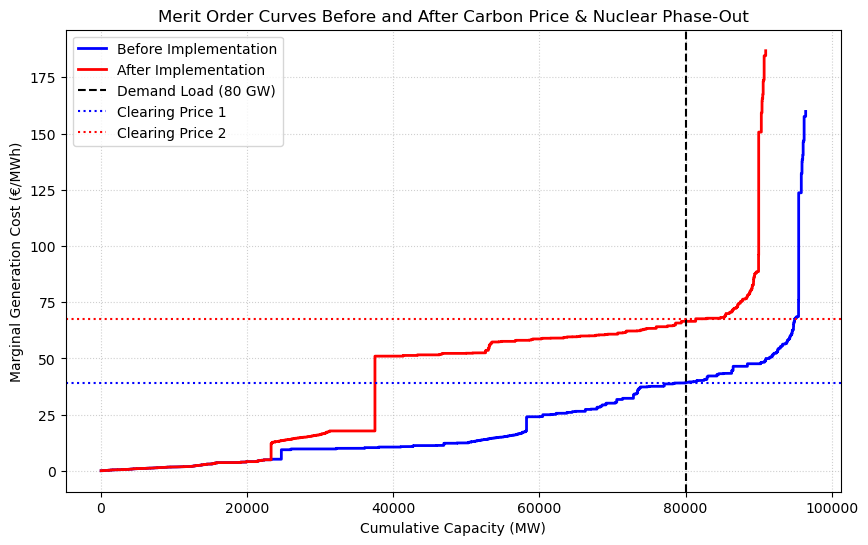

In [ ]:
# YOUR CODE HERE
plt.figure(figsize=(10, 6))
df_sorted_1 = df.sort_values(by='marginal_cost')
plt.step(df_sorted_1['available_capacity'].cumsum(), df_sorted_1['marginal_cost'], 
         where='post', label='Before Implementation', color='blue', linewidth=2)
plt.step(df_sorted['available_capacity_2'].cumsum(), df_sorted['marginal_cost_2'], 
         where='post', label='After Implementation', color='red', linewidth=2)

plt.axvline(x=80000, color='black', linestyle='--', label='Demand Load (80 GW)')
plt.axhline(y=market_clearing_price, color='blue', linestyle=':', label='Clearing Price 1')
plt.axhline(y=market_clearing_price2, color='red', linestyle=':', label='Clearing Price 2')
plt.xlabel('Cumulative Capacity (MW)')
plt.ylabel('Marginal Generation Cost (€/MWh)')
plt.title('Merit Order Curves Before and After Carbon Price & Nuclear Phase-Out')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()